In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# a)  Planeje um experimento na sua área de atuação no delineamento casualizado em blocos.

5 tratamentos (diferentes lâminas de irrigação: 40%, 60%, 80%, 100%, 120%)

8 blocos

Total de 40 parcelas

In [44]:
# Tratamentos (diferentes lâminas de irrigação)
tratamentos = ['40', '60', '80', '100', '120']

# 8 blocos (repetições)
blocos = [f'Bloco{i+1}' for i in range(8)]

# Médias hipotéticas de produtividade para cada tratamento
medias = {
    '40': 5800,
    '60': 6800,
    '80': 7700,
    '100': 8300,
    '120': 8000
}

# Simular os dados
np.random.seed(42)  # para reprodutibilidade
dados = []

for bloco in blocos:
    for tratamento in tratamentos:
        prod = np.random.normal(loc=medias[tratamento], scale=200)
        dados.append({
            'Bloco': bloco,
            'Lamina': tratamento,
            'Produtividade': round(prod, 1)
        })

# Criar DataFrame
df = pd.DataFrame(dados)
df


# Exportar (opcional)
# df_irrig.to_csv('dados_irrigacao_blocos_tratamentos.csv', index=False)


,Bloco,Lamina,Produtividade
0,Bloco1,40,5899.3
1,Bloco1,60,6772.3
2,Bloco1,80,7829.5
3,Bloco1,100,8604.6
4,Bloco1,120,7953.2
5,Bloco2,40,5753.2
6,Bloco2,60,7115.8
7,Bloco2,80,7853.5
8,Bloco2,100,8206.1
9,Bloco2,120,8108.5


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Bloco          40 non-null     object 
 1   Lamina         40 non-null     object 
 2   Produtividade  40 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.1+ KB


- Transformando a coluna Lamina para números inteiros, estava como __objeto__.

In [46]:
df['Lamina'] = df['Lamina'].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Bloco          40 non-null     object 
 1   Lamina         40 non-null     int64  
 2   Produtividade  40 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


---
## ANOVA

In [47]:
modelo = smf.ols('Produtividade ~ C(Lamina) + C(Bloco)', data=df).fit()
anova = sm.stats.anova_lm(modelo, typ=2)
print(anova)

                 sum_sq    df           F        PR(>F)
C(Lamina)  3.074632e+07   4.0  257.162608  1.231371e-21
C(Bloco)   4.217336e+05   7.0    2.015649  8.854704e-02
Residual   8.369188e+05  28.0         NaN           NaN


---
## Normalidade

In [33]:
residuos = modelo.resid
shapiro = stats.shapiro(residuos)
print("\n--- TESTE DE NORMALIDADE (Shapiro-Wilk) ---")
print(f"Estatística W = {shapiro.statistic:.4f}, p-valor = {shapiro.pvalue:.4f}")


--- TESTE DE NORMALIDADE (Shapiro-Wilk) ---
Estatística W = 0.9733, p-valor = 0.4546


---
## Homogeneidade

In [34]:
grupo_trat = [df[df['Lamina'] == t]['Produtividade'] for t in df['Lamina'].unique()]
levene = stats.levene(*grupo_trat)
print("\n--- TESTE DE HOMOGENEIDADE (Levene) ---")
print(f"Estatística = {levene.statistic:.4f}, p-valor = {levene.pvalue:.4f}")


--- TESTE DE HOMOGENEIDADE (Levene) ---
Estatística = 0.2360, p-valor = 0.9162


---
## Regressão

In [48]:
# ---------- 6. REGRESSÃO (tratamento como variável numérica) ----------
# Extrair os números da lâmina para regressão
modelo_linear = smf.ols('Produtividade ~ Lamina', data=df).fit()
print("\n--- REGRESSÃO SIMPLES ---")
print(modelo_linear.summary())


--- REGRESSÃO SIMPLES ---
                            OLS Regression Results                            
Dep. Variable:          Produtividade   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     149.4
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           9.72e-15
Time:                        23:02:22   Log-Likelihood:                -296.69
No. Observations:                  40   AIC:                             597.4
Df Residuals:                      38   BIC:                             600.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5017.2400    

In [50]:
modelo_quadratico = smf.ols('Produtividade ~ I(Lamina**2)', data=df).fit()
print("--- Resumo do Modelo de Regressão Quadrático ---")
print(modelo_quadratico.summary())

--- Resumo do Modelo de Regressão Quadrático ---
                            OLS Regression Results                            
Dep. Variable:          Produtividade   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     81.16
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           5.72e-11
Time:                        23:02:42   Log-Likelihood:                -305.75
No. Observations:                  40   AIC:                             615.5
Df Residuals:                      38   BIC:                             618.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

---
## Plot da regressão

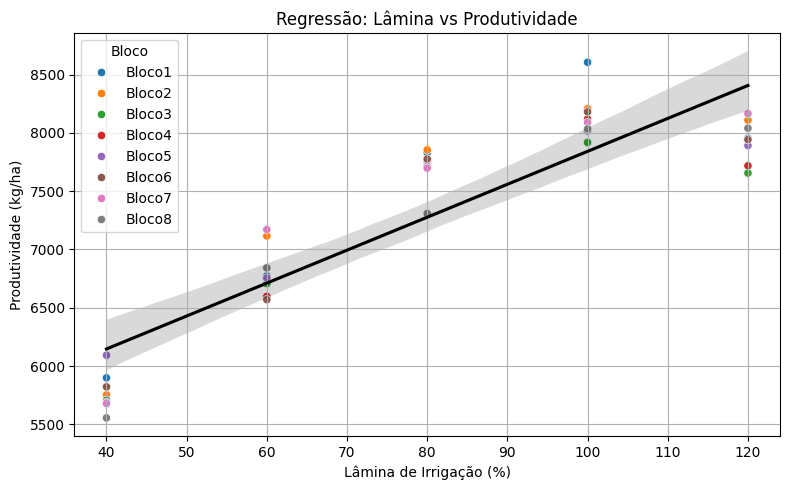

In [ ]:
# ---------- 7. PLOT DA REGRESSÃO ----------
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Lamina', y='Produtividade', hue='Bloco')
sns.regplot(data=df, x='Lamina', y='Produtividade', scatter=False, color='black', ci=95)
plt.title('Regressão: Lâmina vs Produtividade')
plt.xlabel('Lâmina de Irrigação (%)')
plt.ylabel('Produtividade (kg/ha)')
plt.grid(True)
plt.tight_layout()
plt.show()

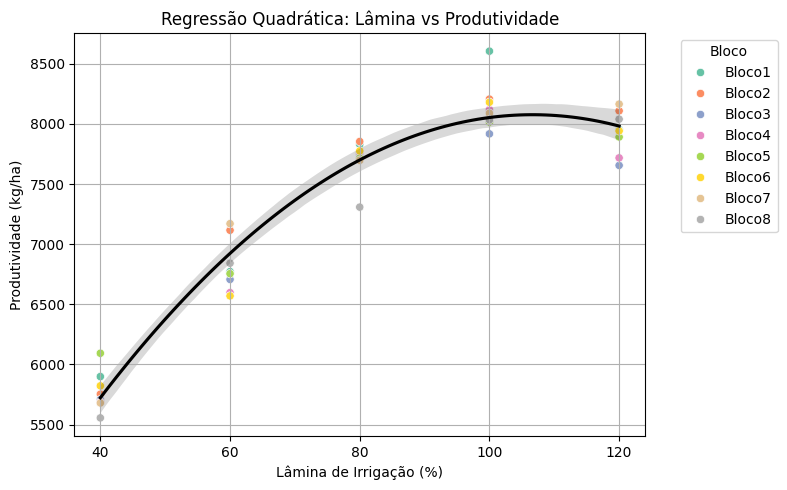

In [56]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Lamina', y='Produtividade', hue='Bloco', palette='Set2')
sns.regplot(data=df, x='Lamina', y='Produtividade', order=2,scatter=False, color='black')
plt.title('Regressão Quadrática: Lâmina vs Produtividade')
plt.xlabel('Lâmina de Irrigação (%)')
plt.ylabel('Produtividade (kg/ha)')
plt.xticks([40, 60, 80, 100, 120])
plt.legend(title='Bloco', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## De acordo com a análise de variância (ANOVA), ao nível de 5% de significância, rejeitou-se a hipótese nula, indicando que ao menos uma das médias de produtividade diferiu significativamente das demais. Os pressupostos de normalidade dos resíduos e homogeneidade de variâncias foram verificados e atendidos, conferindo validade ao teste. Em seguida, foi realizada uma análise de regressão, apropriada ao se tratar de variáveis quantitativas. Os resultados indicaram que o modelo linear apresentou melhor ajuste aos dados, com um coeficiente de determinação (R²) de 0,79, superior ao do modelo quadrático, cujo R² foi de 0,68.